# 🧠 Modelo 3: Transfer Learning (VGG16)

Este notebook utiliza el modelo VGG16 preentrenado para clasificar las imágenes OCT. El modelo se carga desde `modelos/modelo_transfer.py`.

---

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

# Añadir el directorio raíz al path para importar módulos locales
sys.path.append('..')
import oct_dataloader as dataloaders
import modelos.modelo_transfer as transfer_model

print("✅ Librerías importadas")

✅ Librerías importadas


c:\Users\pablo\miniconda3\envs\oct_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configurar GPUs si están disponibles
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
print(gpus)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
# Descargar y preparar dataset en carpeta local (Disco D)
path = kagglehub.dataset_download("anirudhcv/labeled-optical-coherence-tomography-oct")
data_path = path
for root, dirs, files in os.walk(path):
    if 'train' in dirs and 'test' in dirs:
        data_path = root
        break

print(f"✅ Dataset en: {data_path}")

# Hiperparámetros de carga
IMG_SIZE = (128, 128) 
BATCH_SIZE = 64

train_ds, val_ds, test_ds, class_names = dataloaders.create_oct_dataloaders(
    data_path=data_path,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb', # Cambiamos a RGB para VGG16
    train_subset_fraction=0.8, # Solo 20% para que sea rápido en Transfer Learning
    optimize=False
)

✅ Dataset en: C:\Users\pablo\.cache\kagglehub\datasets\anirudhcv\labeled-optical-coherence-tomography-oct\versions\2\Dataset - train+val+test
⚙️ Configuración de DataLoaders
   • Tamaño de imagen: (128, 128)
   • Batch size: 64
   • Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
   • Train subset: 80.0%
   • Seed: 42

📦 Creando data loader de entrenamiento...
Found 76515 files belonging to 4 classes.
   ⚠️  Usando 80.0% del dataset de entrenamiento
   ⚠️  Batches: 956 de 1196
✅ Data loader de entrenamiento creado

📦 Creando data loader de validación...
Found 21861 files belonging to 4 classes.
✅ Data loader de validación creado

📦 Creando data loader de prueba...
Found 10933 files belonging to 4 classes.
✅ Data loader de prueba creado

📊 RESUMEN DE DATASETS
Train:      956 batches
Validation: 342 batches
Test:       171 batches



In [9]:
# Crear y compilar el modelo
model = transfer_model.create_transfer_model(input_shape=(128, 128, 3), num_classes=4)
model = transfer_model.compile_model(model)
transfer_model.print_model_summary(model)

Model: "TransferVGG16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 global_average_pooling2d_1   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_2 (Dense)             (None, 256)               131328    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 4)                 1028      
                                                                 
Total params: 14,847,044
Trainable params: 132,356
Non-trainable params: 14,714,688
___________________________________

In [10]:
# Entrenamiento (de la parte densa únicamente)
EPOCHS = 100
callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/100
956/956 [==============================] - 87s 90ms/step - loss: 0.6360 - accuracy: 0.8049 - val_loss: 0.4233 - val_accuracy: 0.8513
Epoch 2/100
956/956 [==============================] - 88s 92ms/step - loss: 0.4228 - accuracy: 0.8541 - val_loss: 0.3765 - val_accuracy: 0.8667
Epoch 3/100
956/956 [==============================] - 89s 93ms/step - loss: 0.3915 - accuracy: 0.8634 - val_loss: 0.3660 - val_accuracy: 0.8705
Epoch 4/100
956/956 [==============================] - 92s 96ms/step - loss: 0.3714 - accuracy: 0.8698 - val_loss: 0.3481 - val_accuracy: 0.8745
Epoch 5/100
956/956 [==============================] - 87s 90ms/step - loss: 0.3551 - accuracy: 0.8758 - val_loss: 0.3445 - val_accuracy: 0.8800
Epoch 6/100
956/956 [==============================] - 87s 91ms/step - loss: 0.3398 - accuracy: 0.8808 - val_loss: 0.3419 - val_accuracy: 0.8780
Epoch 7/100
956/956 [==============================] - 88s 92ms/step - loss: 0.3273 - accuracy: 0.8853 - val_loss: 0.3386 - val_ac

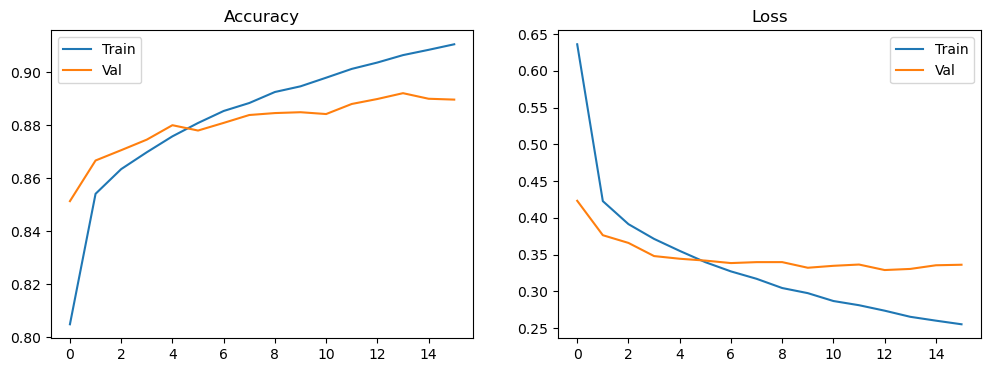

In [11]:
# Curvas de aprendizaje
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()

In [12]:
# Evaluación final
loss_train, acc_train = model.evaluate(train_ds, verbose=0)
loss_val, acc_val = model.evaluate(val_ds, verbose=0)
loss_test, acc_test = model.evaluate(test_ds, verbose=0)

print(f"Resultados: Train={acc_train:.4f}, Val={acc_val:.4f}, Test={acc_test:.4f}")
print(f"Parámetros totales: {model.count_params():,}")

Resultados: Train=0.9215, Val=0.8898, Test=0.8869
Parámetros totales: 14,847,044
